In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [7]:
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [8]:
train_dir = "/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/train"

test_dir = "/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/test"

In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 8723 images belonging to 6 classes.
Found 2178 images belonging to 6 classes.
Found 2698 images belonging to 6 classes.


In [10]:
print(train_generator.class_indices)

{'freshapples': 0, 'freshbanana': 1, 'freshoranges': 2, 'rottenapples': 3, 'rottenbanana': 4, 'rottenoranges': 5}


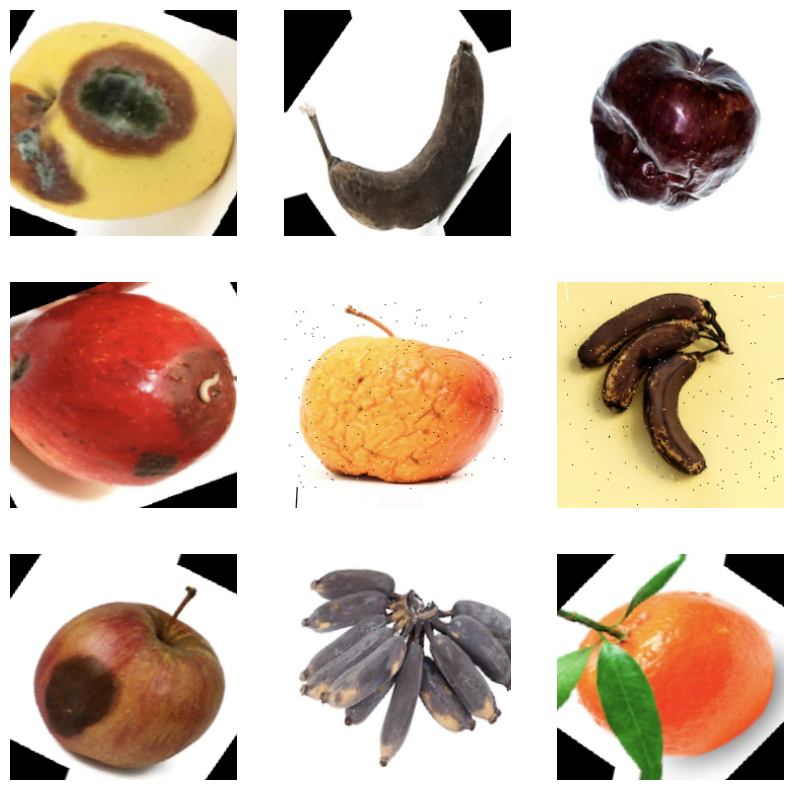

In [90]:
images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")
pdf_path = "/kaggle/working/sample_images.pdf"
plt.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")

plt.show()

In [12]:
cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu',
           input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(6, activation='softmax')

])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1782654397.752374      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782654397.758391      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,246,214 (84.86 MB)

 Trainable params: 22,246,214 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

train_dir = "/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/train"

test_dir = "/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/test"


In [14]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15


I0000 00:00:1782654403.253737     160 service.cc:152] XLA service 0x7ae84c004750 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782654403.253777     160 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782654403.253781     160 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782654403.754948     160 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-28 13:46:47.201055: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 13:46:47.349329: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  2/273 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.1875 - loss: 2.1235 

I0000 00:00:1782654410.648464     160 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


273/273 ━━━━━━━━━━━━━━━━━━━━ 231s 815ms/step - accuracy: 0.7233 - loss: 0.7590 - val_accuracy: 0.8811 - val_loss: 0.3662
Epoch 2/15
273/273 ━━━━━━━━━━━━━━━━━━━━ 158s 579ms/step - accuracy: 0.8498 - loss: 0.4230 - val_accuracy: 0.9123 - val_loss: 0.2373
Epoch 3/15
273/273 ━━━━━━━━━━━━━━━━━━━━ 154s 565ms/step - accuracy: 0.8724 - loss: 0.3509 - val_accuracy: 0.9132 - val_loss: 0.2356
Epoch 4/15
273/273 ━━━━━━━━━━━━━━━━━━━━ 152s 557ms/step - accuracy: 0.8941 - loss: 0.3003 - val_accuracy: 0.9233 - val_loss: 0.1946
Epoch 5/15
273/273 ━━━━━━━━━━━━━━━━━━━━ 153s 561ms/step - accuracy: 0.9057 - loss: 0.2642 - val_accuracy: 0.9325 - val_loss: 0.1736
Epoch 6/15
273/273 ━━━━━━━━━━━━━━━━━━━━ 155s 567ms/step - accuracy: 0.9115 - loss: 0.2309 - val_accuracy: 0.9532 - val_loss: 0.1256
Epoch 7/15
273/273 ━━━━━━━━━━━━━━━━━━━━ 154s 562ms/step - accuracy: 0.9173 - loss: 0.2260 - val_accuracy: 0.9380 - val_loss: 0.1567
Epoch 8/15
273/273 ━━━━━━━━━━━━━━━━━━━━ 154s 563ms/step - accuracy: 0.9293 - loss: 0.20

In [16]:
test_loss, test_acc = cnn_model.evaluate(test_generator)

print("CNN Test Accuracy:", test_acc)

85/85 ━━━━━━━━━━━━━━━━━━━━ 37s 433ms/step - accuracy: 0.9770 - loss: 0.0675
CNN Test Accuracy: 0.9770200252532959


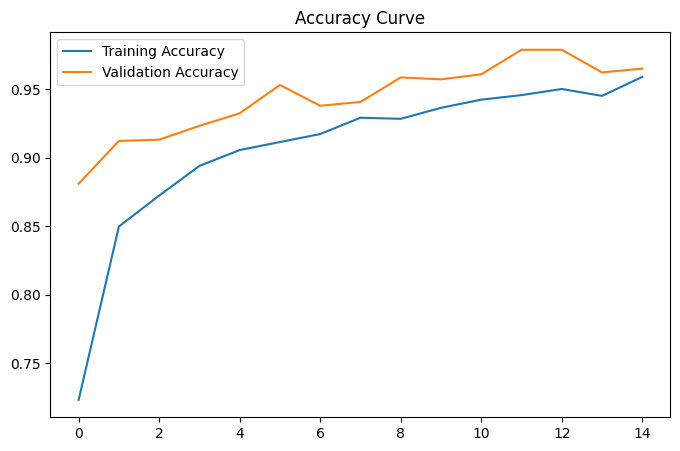

In [89]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.legend()
plt.title("Accuracy Curve")
pdf_path = "/kaggle/working/cnn_accuracy_curve.pdf"
plt.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")

plt.show()

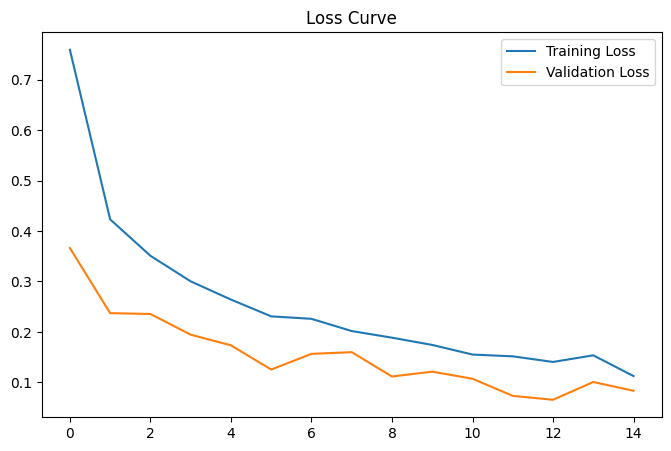

In [88]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.legend()
plt.title("Loss Curve")
pdf_path = "/kaggle/working/cnn_loss_curve.pdf"
plt.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")

plt.show()

In [19]:
predictions = cnn_model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)

y_true = test_generator.classes

85/85 ━━━━━━━━━━━━━━━━━━━━ 14s 159ms/step


In [20]:
class_names = list(test_generator.class_indices.keys())

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

               precision    recall  f1-score   support

  freshapples       0.94      1.00      0.97       395
  freshbanana       1.00      0.98      0.99       381
 freshoranges       0.98      0.96      0.97       388
 rottenapples       0.98      0.96      0.97       601
 rottenbanana       1.00      1.00      1.00       530
rottenoranges       0.97      0.97      0.97       403

     accuracy                           0.98      2698
    macro avg       0.98      0.98      0.98      2698
 weighted avg       0.98      0.98      0.98      2698



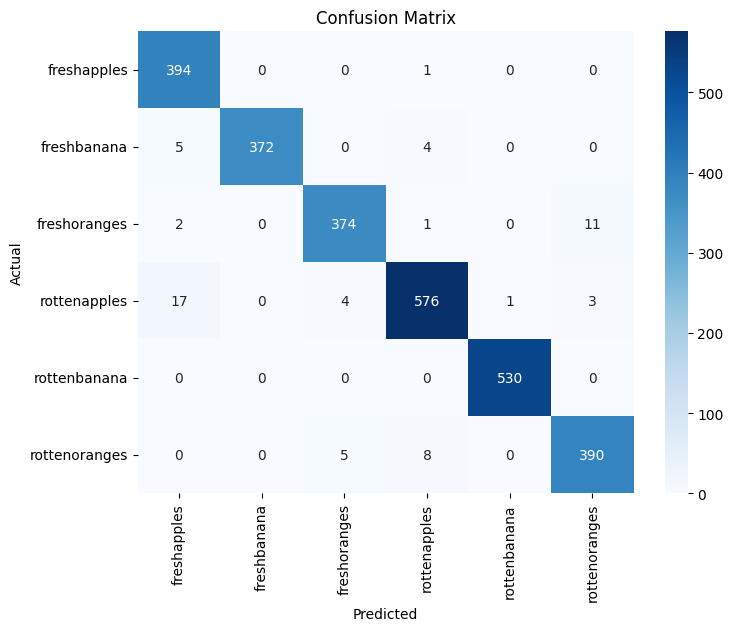

Confusion Matrix saved to: /kaggle/working/cnn_cm.pdf


In [87]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Reset the generator
test_generator.reset()

# Predict probabilities
y_pred = cnn_model.predict(test_generator, verbose=0)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred, axis=1)

# True labels
y_true = test_generator.classes

# Class names
class_names = list(test_generator.class_indices.keys())

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

# Save as PDF
pdf_path = "/kaggle/working/cnn_cm.pdf"
plt.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")

plt.show()

print("Confusion Matrix saved to:", pdf_path)

In [22]:
test_loss, test_acc = cnn_model.evaluate(test_generator)

print("CNN Test Accuracy:", test_acc)

85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 156ms/step - accuracy: 0.9770 - loss: 0.0675
CNN Test Accuracy: 0.9770200252532959


In [23]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

               precision    recall  f1-score   support

  freshapples       0.94      1.00      0.97       395
  freshbanana       1.00      0.98      0.99       381
 freshoranges       0.98      0.96      0.97       388
 rottenapples       0.98      0.96      0.97       601
 rottenbanana       1.00      1.00      1.00       530
rottenoranges       0.97      0.97      0.97       403

     accuracy                           0.98      2698
    macro avg       0.98      0.98      0.98      2698
 weighted avg       0.98      0.98      0.98      2698



In [24]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [25]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [26]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

predictions = Dense(
    6,
    activation='softmax'
)(x)

mobilenet_model = Model(
    inputs=base_model.input,
    outputs=predictions
)

In [27]:
mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
mobilenet_history = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10


2026-06-28 14:27:45.884423: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 14:27:46.022310: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  7/273 ━━━━━━━━━━━━━━━━━━━━ 1:47 402ms/step - accuracy: 0.3447 - loss: 1.6676

2026-06-28 14:27:59.098067: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 14:27:59.234179: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 14:27:59.371823: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.8782 - loss: 0.3284

2026-06-28 14:30:51.399165: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 14:30:51.536130: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 14:30:51.672617: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


273/273 ━━━━━━━━━━━━━━━━━━━━ 203s 682ms/step - accuracy: 0.9418 - loss: 0.1594 - val_accuracy: 0.9812 - val_loss: 0.0562
Epoch 2/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 157s 574ms/step - accuracy: 0.9801 - loss: 0.0566 - val_accuracy: 0.9885 - val_loss: 0.0306
Epoch 3/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 158s 579ms/step - accuracy: 0.9885 - loss: 0.0356 - val_accuracy: 0.9683 - val_loss: 0.0834
Epoch 4/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 156s 572ms/step - accuracy: 0.9859 - loss: 0.0380 - val_accuracy: 0.9940 - val_loss: 0.0161
Epoch 5/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 153s 560ms/step - accuracy: 0.9943 - loss: 0.0188 - val_accuracy: 0.9972 - val_loss: 0.0103
Epoch 6/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 153s 562ms/step - accuracy: 0.9909 - loss: 0.0234 - val_accuracy: 0.9986 - val_loss: 0.0078
Epoch 7/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 154s 566ms/step - accuracy: 0.9911 - loss: 0.0225 - val_accuracy: 0.9972 - val_loss: 0.0063
Epoch 8/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 153s 559ms/step - accuracy: 0.9915 - loss: 0.02

In [29]:
mobile_loss, mobile_acc = mobilenet_model.evaluate(test_generator)

print("MobileNetV2 Accuracy:", mobile_acc)

84/85 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9881 - loss: 0.0352

2026-06-28 14:54:26.165524: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 14:54:26.302966: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 14:54:26.439959: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


85/85 ━━━━━━━━━━━━━━━━━━━━ 25s 295ms/step - accuracy: 0.9830 - loss: 0.0622
MobileNetV2 Accuracy: 0.9829503297805786


In [35]:
from sklearn.metrics import confusion_matrix

85/85 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step


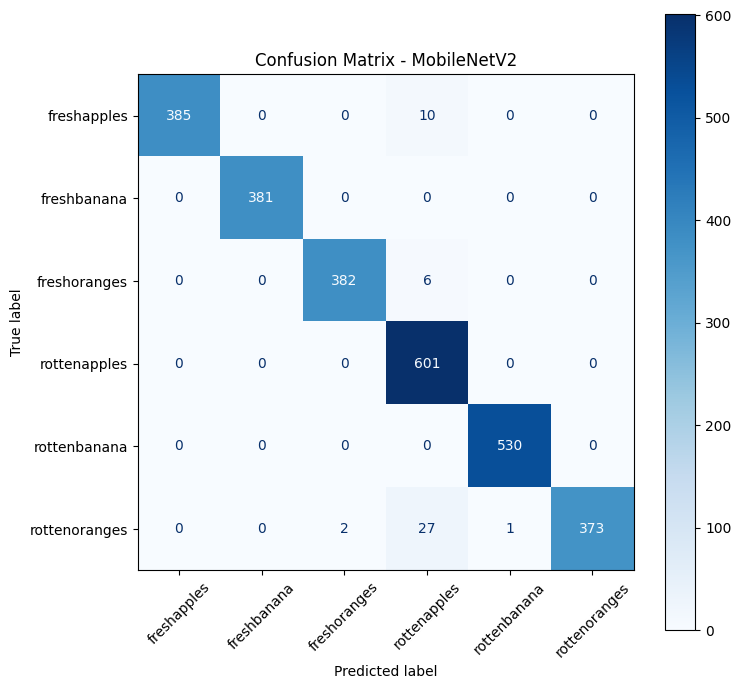

In [84]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Predict
y_pred = mobilenet_model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = test_generator.classes

# Class names
class_names = list(test_generator.class_indices.keys())

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - MobileNetV2")
pdf_path = "/kaggle/working/Mobilenetv2_cm.pdf"
plt.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")
plt.show()

In [38]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))

               precision    recall  f1-score   support

  freshapples       1.00      0.97      0.99       395
  freshbanana       1.00      1.00      1.00       381
 freshoranges       0.99      0.98      0.99       388
 rottenapples       0.93      1.00      0.97       601
 rottenbanana       1.00      1.00      1.00       530
rottenoranges       1.00      0.93      0.96       403

     accuracy                           0.98      2698
    macro avg       0.99      0.98      0.98      2698
 weighted avg       0.98      0.98      0.98      2698



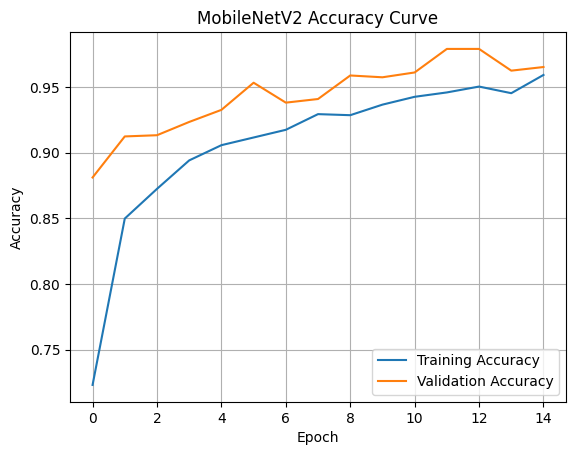

In [91]:
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.title("MobileNetV2 Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
pdf_path = "/kaggle/working/mobilenetv2_accuracy_curve.pdf"
plt.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")

plt.show()

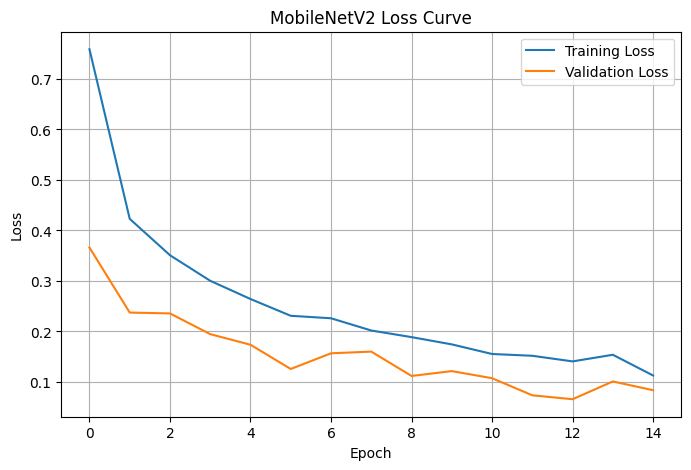

In [83]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.title("MobileNetV2 Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

pdf_path = "/kaggle/working/MobileNetV2_loss_curve.pdf"
plt.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")



plt.show()

In [52]:
import shap



In [53]:
# Reset generator
train_generator.reset()

# Take one batch of training images
background_images, _ = next(train_generator)

# Use first 50 images as background
background = background_images[:50]

In [55]:
explainer = shap.GradientExplainer(
    mobilenet_model,
    background
)

In [56]:
# Reset test generator
test_generator.reset()

# Get one batch
test_images, test_labels = next(test_generator)

# Explain first 5 images
sample_images = test_images[:5]

In [57]:
shap_values = explainer.shap_values(sample_images)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_21
Received: inputs=['Tensor(shape=(5, 224, 224, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_21
Received: inputs=['Tensor(shape=(50, 224, 224, 3))']
  warnings.warn(msg)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.647962098009884e-09..5.305992090143263e-09].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.43833414465189e-09..4.212779458612204e-09].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-7.741618901491165e-09..8.061761036515236e-09].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-7.4214767664670944e-09..6.606569513678551e-09].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-6.003119779052213e-09..7.961716619320214e-09].


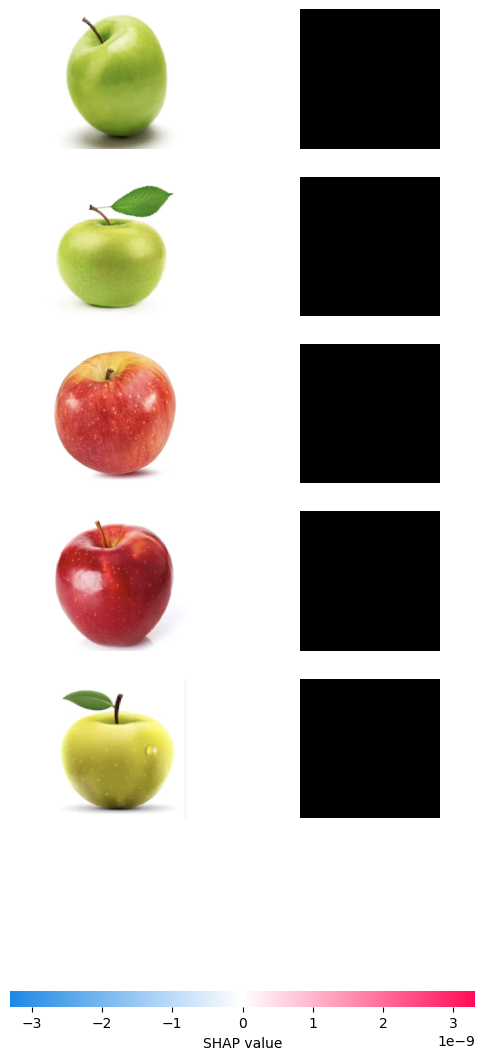

SHAP analysis saved successfully at:
/kaggle/working/SHAP_Analysis_All_Fruits.pdf


<Figure size 640x480 with 0 Axes>

In [82]:
shap.image_plot(shap_values, sample_images)
pdf_path = "/kaggle/working/SHAP_Analysis_All_Fruits.pdf"
plt.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")

print(f"SHAP analysis saved successfully at:\n{pdf_path}")

plt.show()

In [59]:
# Print all layers (Run once)
for layer in mobilenet_model.layers:
    print(layer.name)

input_layer_1
Conv1
bn_Conv1
Conv1_relu
expanded_conv_depthwise
expanded_conv_depthwise_BN
expanded_conv_depthwise_relu
expanded_conv_project
expanded_conv_project_BN
block_1_expand
block_1_expand_BN
block_1_expand_relu
block_1_pad
block_1_depthwise
block_1_depthwise_BN
block_1_depthwise_relu
block_1_project
block_1_project_BN
block_2_expand
block_2_expand_BN
block_2_expand_relu
block_2_depthwise
block_2_depthwise_BN
block_2_depthwise_relu
block_2_project
block_2_project_BN
block_2_add
block_3_expand
block_3_expand_BN
block_3_expand_relu
block_3_pad
block_3_depthwise
block_3_depthwise_BN
block_3_depthwise_relu
block_3_project
block_3_project_BN
block_4_expand
block_4_expand_BN
block_4_expand_relu
block_4_depthwise
block_4_depthwise_BN
block_4_depthwise_relu
block_4_project
block_4_project_BN
block_4_add
block_5_expand
block_5_expand_BN
block_5_expand_relu
block_5_depthwise
block_5_depthwise_BN
block_5_depthwise_relu
block_5_project
block_5_project_BN
block_5_add
block_6_expand
block_6_

In [68]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output,
         model.output]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap,0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

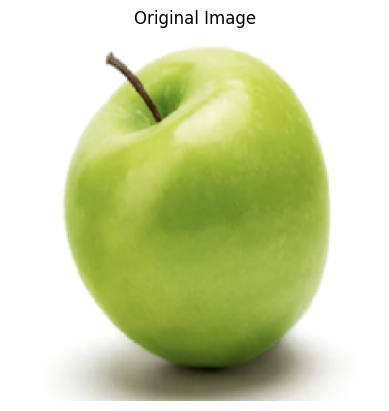

In [69]:
# Reset generator
test_generator.reset()

images, labels = next(test_generator)

# First image
img = images[0]

plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [78]:
import cv2
import random

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_21']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


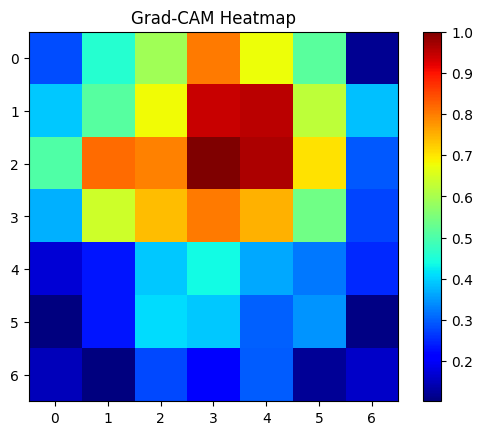

In [70]:
img_array = np.expand_dims(img, axis=0)

heatmap = make_gradcam_heatmap(
    img_array,
    mobilenet_model,
    last_conv_layer_name="Conv_1"
)

plt.imshow(heatmap, cmap="jet")
plt.colorbar()
plt.title("Grad-CAM Heatmap")
plt.show()

PDF saved successfully as: GradCAM_All_Fruits.pdf


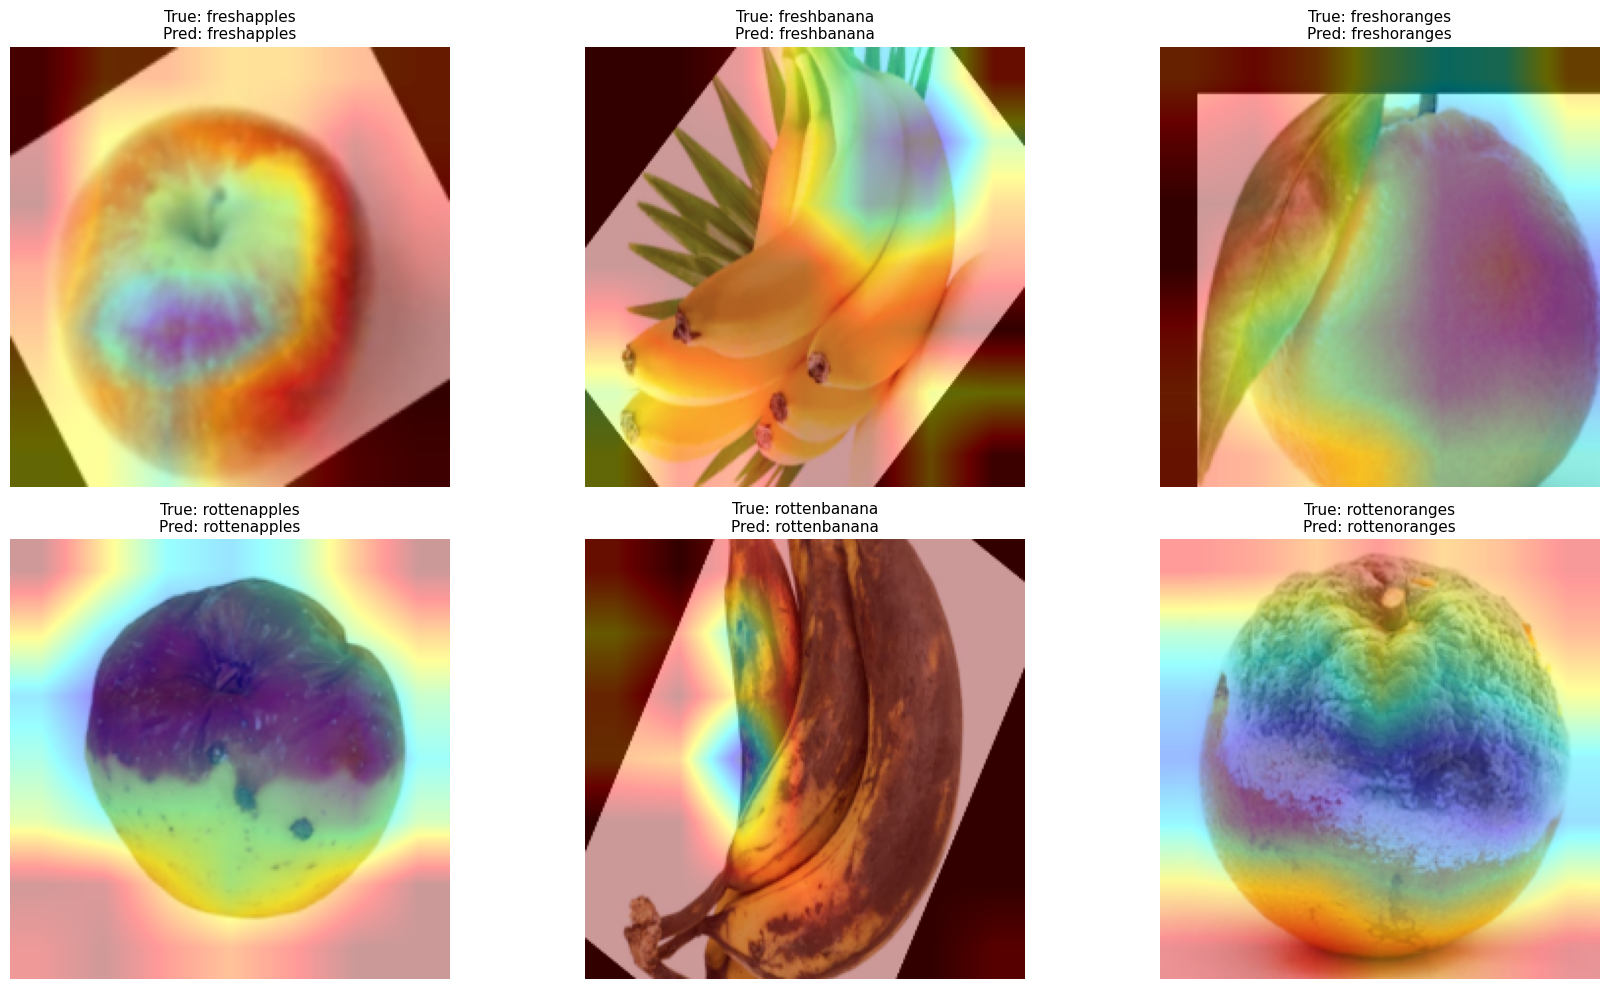

In [80]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Class names
class_names = list(test_generator.class_indices.keys())

# Last convolution layer of MobileNetV2
last_conv_layer_name = "Conv_1"

# Create figure
fig = plt.figure(figsize=(18,10))

for i, class_name in enumerate(class_names):

    # Folder containing images of the class
    class_folder = os.path.join(test_dir, class_name)

    # Random image from the folder
    image_name = random.choice(os.listdir(class_folder))
    image_path = os.path.join(class_folder, image_name)

    # Read image
    original = cv2.imread(image_path)
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    # Resize image
    resized = cv2.resize(original, (224,224))

    img = resized.astype("float32") / 255.0
    img_array = np.expand_dims(img, axis=0)

    # Generate Grad-CAM heatmap
    heatmap = make_gradcam_heatmap(
        img_array,
        mobilenet_model,
        last_conv_layer_name
    )

    # Resize heatmap
    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Overlay heatmap
    overlay = cv2.addWeighted(
        np.uint8(resized),
        0.6,
        heatmap,
        0.4,
        0
    )

    # Prediction
    prediction = mobilenet_model.predict(img_array, verbose=0)
    pred_class = class_names[np.argmax(prediction)]

    ax = fig.add_subplot(2,3,i+1)
    ax.imshow(overlay)
    ax.set_title(f"True: {class_name}\nPred: {pred_class}", fontsize=11)
    ax.axis("off")

# Adjust layout
plt.tight_layout()

# ===== Save as PDF =====
pdf_name = "GradCAM_All_Fruits.pdf"
plt.savefig(pdf_name, format="pdf", dpi=300, bbox_inches="tight")

print(f"PDF saved successfully as: {pdf_name}")

# Show figure
plt.show()

In [93]:
pip install streamlit tensorflow pillow numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 65.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 82.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 107.4 MB/s eta 0:00:0000:010:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requir

In [97]:
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
import os

print(os.listdir("/kaggle/working"))

['Mobilenetv2_cm.pdf', 'GradCAM_All_Fruits.pdf', 'cnn_cm.pdf', 'MobileNetV2_loss_curve.pdf', 'sample_images.pdf', 'SHAP_Analysis_All_Fruits.pdf', 'mobilenetv2_accuracy_curve.pdf', 'cnn_accuracy_curve.pdf', '.virtual_documents', 'cnn_loss_curve.pdf']


In [98]:
mobilenet_model.save("/kaggle/working/mobilenet_model.h5")

print("Model saved successfully!")

Model saved successfully!


In [99]:
cnn_model.save("/kaggle/working/cnn_model.h5")

print("Model saved successfully!")

Model saved successfully!


In [100]:
import os

print(os.listdir("/kaggle/working"))

['Mobilenetv2_cm.pdf', 'GradCAM_All_Fruits.pdf', 'mobilenet_model.h5', 'cnn_cm.pdf', 'MobileNetV2_loss_curve.pdf', 'sample_images.pdf', 'SHAP_Analysis_All_Fruits.pdf', 'mobilenetv2_accuracy_curve.pdf', 'cnn_accuracy_curve.pdf', '.virtual_documents', 'cnn_loss_curve.pdf', 'cnn_model.h5']


In [101]:
from tensorflow.keras.models import load_model

model = load_model("/kaggle/working/mobilenet_model.h5")